📚 1. Import Libraries

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
data=pd.read_csv("student_carer.csv")
data.head(5)

,Python,SQL,Statistics,MachineLearning,HTML_CSS,JavaScript,Cloud,ProblemSolving,Communication,Creativity,CGPA,Interest,Role
0,3,3,1,3,1,0,1,3,3,2,2.52,AI,AI Engineer
1,3,3,1,3,3,2,0,2,1,2,3.50,AI,AI Engineer
2,1,1,1,0,3,2,1,0,3,1,2.71,Development,Web Developer
3,1,0,2,0,0,1,2,3,2,1,3.80,Cloud,DevOps Engineer
4,2,2,1,1,2,1,2,3,2,2,3.58,Development,Software Engineer


In [104]:
data['Role'].unique()

array([0, 7, 5, 6, 4, 1, 3, 2])

📊 EDA - Exploratory Data

In [83]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Python           2000 non-null   int64  
 1   SQL              2000 non-null   int64  
 2   Statistics       2000 non-null   int64  
 3   MachineLearning  2000 non-null   int64  
 4   HTML_CSS         2000 non-null   int64  
 5   JavaScript       2000 non-null   int64  
 6   Cloud            2000 non-null   int64  
 7   ProblemSolving   2000 non-null   int64  
 8   Communication    2000 non-null   int64  
 9   Creativity       2000 non-null   int64  
 10  CGPA             2000 non-null   float64
 11  Interest         2000 non-null   object 
 12  Role             2000 non-null   object 
dtypes: float64(1), int64(10), object(2)
memory usage: 203.3+ KB
None


In [84]:
print(data['Role'].value_counts())

Role
Cyber Security Analyst    269
Web Developer             268
Cloud Engineer            251
Software Engineer         250
AI Engineer               249
DevOps Engineer           243
Data Scientist            237
Database Administrator    233
Name: count, dtype: int64


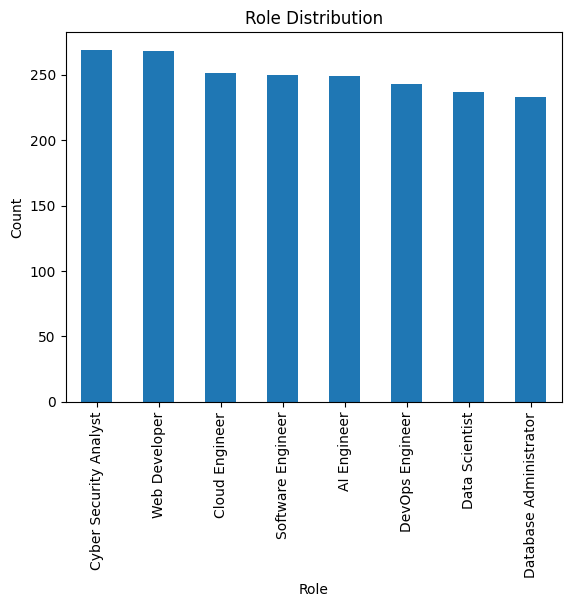

In [85]:


data['Role'].value_counts().plot(kind='bar')
plt.title("Role Distribution")
plt.xlabel("Role")
plt.ylabel("Count")
plt.show()


In [86]:
print(data['Interest'].value_counts())

Interest
Development    518
Cloud          494
Security       269
AI             249
Data           237
Database       233
Name: count, dtype: int64


🧹 Step 3: Data Cleaning

In [87]:
data.isnull().sum()

Python             0
SQL                0
Statistics         0
MachineLearning    0
HTML_CSS           0
JavaScript         0
Cloud              0
ProblemSolving     0
Communication      0
Creativity         0
CGPA               0
Interest           0
Role               0
dtype: int64

In [88]:
print(data.duplicated().sum())

0


🔄  Data Preprocessing

In [89]:
from sklearn.preprocessing import LabelEncoder

In [90]:
data=pd.get_dummies(data,columns=['Interest'])
# df = pd.get_dummies(d, columns=['Interest'])

In [91]:
le=LabelEncoder()

In [92]:
data['Role']=le.fit_transform(data['Role'])

In [93]:
data.head(5)

,Python,SQL,Statistics,MachineLearning,HTML_CSS,JavaScript,Cloud,ProblemSolving,Communication,Creativity,CGPA,Role,Interest_AI,Interest_Cloud,Interest_Data,Interest_Database,Interest_Development,Interest_Security
0,3,3,1,3,1,0,1,3,3,2,2.52,0,True,False,False,False,False,False
1,3,3,1,3,3,2,0,2,1,2,3.50,0,True,False,False,False,False,False
2,1,1,1,0,3,2,1,0,3,1,2.71,7,False,False,False,False,True,False
3,1,0,2,0,0,1,2,3,2,1,3.80,5,False,True,False,False,False,False
4,2,2,1,1,2,1,2,3,2,2,3.58,6,False,False,False,False,True,False


In [94]:
data=data.astype(int)

⚖️ Step 5: Feature Selection

In [95]:

X = data.drop('Role', axis=1)
y = data['Role']

✂️ Step 6: Train-Test Split

In [96]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [97]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Python                2000 non-null   int64
 1   SQL                   2000 non-null   int64
 2   Statistics            2000 non-null   int64
 3   MachineLearning       2000 non-null   int64
 4   HTML_CSS              2000 non-null   int64
 5   JavaScript            2000 non-null   int64
 6   Cloud                 2000 non-null   int64
 7   ProblemSolving        2000 non-null   int64
 8   Communication         2000 non-null   int64
 9   Creativity            2000 non-null   int64
 10  CGPA                  2000 non-null   int64
 11  Role                  2000 non-null   int64
 12  Interest_AI           2000 non-null   int64
 13  Interest_Cloud        2000 non-null   int64
 14  Interest_Data         2000 non-null   int64
 15  Interest_Database     2000 non-null   int64
 16  Intere

In [98]:
from sklearn.preprocessing import StandardScaler

# Scaling only numeric features
numeric_features = ['Python', 'SQL', 'Statistics', 'MachineLearning',
                    'HTML_CSS', 'JavaScript', 'Cloud', 'ProblemSolving',
                    'Communication', 'Creativity', 'CGPA']

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

🤖  Model Selection & Training

In [99]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [100]:
import pickle

from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    'DTC': DecisionTreeClassifier(),
    'LR': LogisticRegression(max_iter=1000),
    'RFC': RandomForestClassifier()
}

accuracy = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    result = f"Model: {name} | Accuracy: {acc:.4f}"
    accuracy.append(result)
    if acc > best_acc:
        best_acc = acc
        best_model = model
        best_model_name = name
# Loop ke BAAD, sirf best model ko save karein
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(accuracy)
print(f"Success! The model name is  '{best_model_name}' and (Acc: {best_acc:.4f}) have been saved .")


['Model: DTC | Accuracy: 0.8575', 'Model: LR | Accuracy: 0.8700', 'Model: RFC | Accuracy: 0.8550']
Success! The model name is  'DTC' and (Acc: 0.8775) have been saved .


Clasificaiton report

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       0.44      0.49      0.46        45
           2       1.00      1.00      1.00        46
           3       1.00      1.00      1.00        56
           4       1.00      1.00      1.00        50
           5       0.42      0.38      0.40        45
           6       0.88      1.00      0.93        49
           7       1.00      0.88      0.93        57

    accuracy                           0.85       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.86      0.85      0.85       400



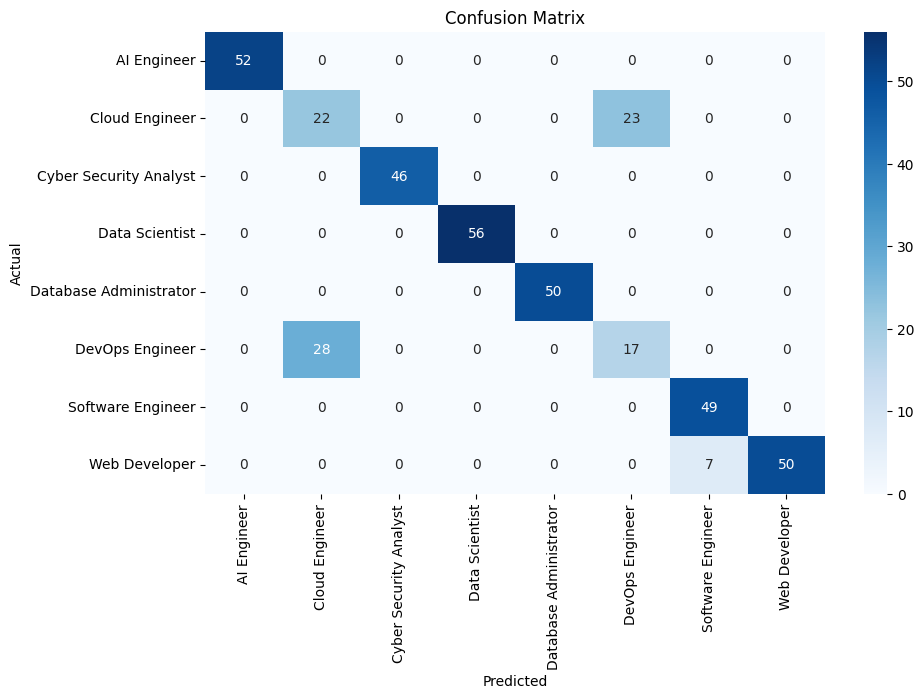

In [101]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy + Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [102]:
data.head()

,Python,SQL,Statistics,MachineLearning,HTML_CSS,JavaScript,Cloud,ProblemSolving,Communication,Creativity,CGPA,Role,Interest_AI,Interest_Cloud,Interest_Data,Interest_Database,Interest_Development,Interest_Security
0,3,3,1,3,1,0,1,3,3,2,2,0,1,0,0,0,0,0
1,3,3,1,3,3,2,0,2,1,2,3,0,1,0,0,0,0,0
2,1,1,1,0,3,2,1,0,3,1,2,7,0,0,0,0,1,0
3,1,0,2,0,0,1,2,3,2,1,3,5,0,1,0,0,0,0
4,2,2,1,1,2,1,2,3,2,2,3,6,0,0,0,0,1,0
